# Decision Tree Complete Teaching Notebook

This notebook explains step-by-step how Decision Trees work using entropy, information gain, and gini.

## Decision Tree Flow
1. Start with dataset
2. Calculate impurity
3. Try splits on features
4. Choose best split
5. Repeat recursively

In [1]:
import pandas as pd

data={
'Outlook':['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
'Temperature':['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
'Humidity':['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
'Wind':['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
'Play':['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df=pd.DataFrame(data)
df

,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


## Entropy Calculation
Entropy measures disorder.

Formula:
Entropy = -Σ p log2(p)

In [2]:
import numpy as np

def entropy(col):
    values,counts=np.unique(col,return_counts=True)
    prob=counts/counts.sum()
    return -(prob*np.log2(prob)).sum()

entropy(df['Play'])

np.float64(0.9402859586706311)

## Information Gain
IG = Entropy(parent) - WeightedEntropy(children)

In [3]:
def information_gain(data,feature,target='Play'):
    total_entropy=entropy(data[target])
    values,counts=np.unique(data[feature],return_counts=True)
    weighted_entropy=0
    for v,c in zip(values,counts):
        subset=data[data[feature]==v]
        weighted_entropy+=(c/len(data))*entropy(subset[target])
    return total_entropy-weighted_entropy

for col in df.columns[:-1]:
    print(col,information_gain(df,col))

Outlook 0.24674981977443933
Temperature 0.02922256565895487
Humidity 0.15183550136234159
Wind 0.04812703040826949


## Gini Index
Gini = 1 - Σ(p²)

In [4]:
def gini(col):
    values,counts=np.unique(col,return_counts=True)
    prob=counts/counts.sum()
    return 1-np.sum(prob**2)

gini(df['Play'])

np.float64(0.4591836734693877)

## Train Decision Tree Model

In [6]:
from sklearn.preprocessing import LabelEncoder

df2=df.copy()
le=LabelEncoder()

for col in df2.columns:
    df2[col]=le.fit_transform(df2[col])

X=df2.drop('Play',axis=1)
y=df2['Play']

In [7]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(criterion='entropy')
model.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

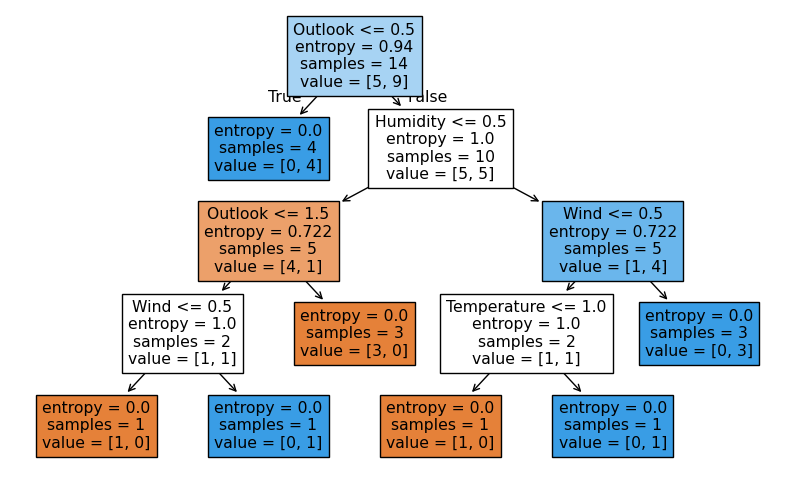

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_tree(model,feature_names=X.columns,filled=True)
plt.show()

## Different Decision Tree Algorithms

### 1. ID3

In [13]:
import pandas as pd

data = pd.DataFrame({
    "Student_ID":[1,2,3,4,5,6,7,8],
    "Study_Hours":[1,2,3,4,5,6,7,8],
    "Sleep_Hours":[8,7,6,5,5,6,7,8],
    "Pass":["No","No","No","Yes","Yes","Yes","Yes","Yes"]
})

data

,Student_ID,Study_Hours,Sleep_Hours,Pass
0,1,1,8,No
1,2,2,7,No
2,3,3,6,No
3,4,4,5,Yes
4,5,5,5,Yes
5,6,6,6,Yes
6,7,7,7,Yes
7,8,8,8,Yes


- Student_ID has unique values → dangerous feature
- Study_Hours is the real predictive feature

In [10]:
# Entropy function
import numpy as np

def entropy(y):
    p = y.value_counts(normalize=True)
    return -np.sum(p * np.log2(p))

In [11]:
# Information Gain (ID3)
def information_gain(data, feature, target="Pass"):
    
    total_entropy = entropy(data[target])
    
    values = data[feature].unique()
    
    weighted_entropy = 0
    
    for v in values:
        subset = data[data[feature]==v]
        weighted_entropy += (len(subset)/len(data)) * entropy(subset[target])
        
    return total_entropy - weighted_entropy

In [14]:
# Calculate IG
for col in ["Student_ID","Study_Hours","Sleep_Hours"]:
    print(col, information_gain(data, col))

Student_ID 0.954434002924965
Study_Hours 0.954434002924965
Sleep_Hours 0.20443400292496505


#### ID3 will choose Student_ID as root, which is completely useless.

### 2. Gain Ratio (C4.5)

Gain Ratio fixes this problem.

    - GainRatio = SplitInformation/InformationGain
	
    - Split Information:−∑pilog2(pi)

In [15]:
def split_info(data, feature):
    
    p = data[feature].value_counts(normalize=True)
    
    return -np.sum(p * np.log2(p))

In [16]:
def gain_ratio(data, feature):
    
    ig = information_gain(data, feature)
    si = split_info(data, feature)
    
    return ig/si

In [17]:
for col in ["Student_ID","Study_Hours","Sleep_Hours"]:
    print(col, gain_ratio(data, col))

Student_ID 0.318144667641655
Study_Hours 0.318144667641655
Sleep_Hours 0.10221700146248253


#### Expected result
`Study_Hours → highest Gain Ratio`

C4.5 correctly selects Study_Hours.

### CART

- **Gini Index (CART)**

In [18]:
def gini(y):
    
    p = y.value_counts(normalize=True)
    
    return 1 - np.sum(p**2)

In [19]:
def gini_split(data, feature, target="Pass"):
    
    values = data[feature].unique()
    
    gini_total = 0
    
    for v in values:
        subset = data[data[feature]==v]
        gini_total += (len(subset)/len(data)) * gini(subset[target])
        
    return gini_total

In [20]:
for col in ["Student_ID","Study_Hours","Sleep_Hours"]:
    print(col, gini_split(data, col))

Student_ID 0.0
Study_Hours 0.0
Sleep_Hours 0.375


#### Expected Result
`Study_Hours → lowest Gini`

- CART correctly selects Study_Hours.

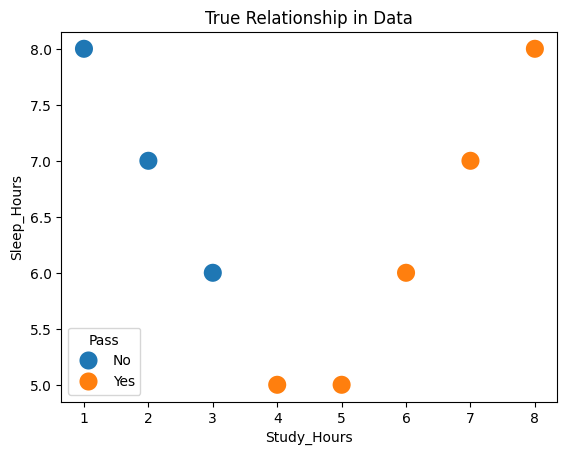

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=data,x="Study_Hours",y="Sleep_Hours",hue="Pass",s=200)

plt.title("True Relationship in Data")
plt.show()

# Pruning

#### Truncation (Pre-pruning)

Stop growth early based on user-defined limits so leaves don’t get too small or the tree too deep.

Common knobs (scikit-learn DecisionTreeClassifier):
- **criterion** = {"gini","entropy"}: impurity measure used to pick splits.
- **max_features**: number of features to consider per split (None, integer, fraction, "sqrt", "log2").
- **max_depth**: maximum depth of the tree.
- **min_samples_split**: minimum samples required to split a node.
- **min_samples_leaf**: minimum samples required in any leaf.
- **max_leaf_nodes**: cap total leaves (forces best-first growth).
- **min_impurity_decrease**: split only if impurity decrease ≥ this threshold.

Mapping to **methods of truncation**
1. Limit min partition size after a split → **min_samples_split**
2. Limit depth → **max_depth**
3. Minimum samples in a leaf → **min_samples_leaf**
4. Limit # leaves → **max_leaf_nodes**
5. Minimize change in homogeneity (require a minimum gain) → **min_impurity_decrease**

#### Pruning (Post-pruning): Balance Fit and Complexity

- As the tree gets deeper, the error in the training data decreases, but the error in the test data may increase. — overfitting
- To prevent overfitting of the decision tree, branches of the complex tree are pruned to create a less complex tree. — pruning
- Initially, the tree is constructed complex enough to have no misclassification cases at the leaf nodes, and then unnecessary branches are pruned. - post pruning
- CCP is a pruning algorithm proposed by Breiman, Stone, and Olsen when they introduced CART in 1984.
- Grow first, then cut back from the bottom. In scikit-learn this is implemented as **cost-complexity pruning via ccp_alpha**. Increasing ccp_alpha penalizes tree size; branches that don’t pull their weight (in impurity reduction) get snipped.

In practice, post-pruning often generalizes better because the tree has the chance to consider complex interactions before we simplify it.

- A very deep tree can fit the training data almost perfectly, but will usually overfit and generalize poorly.
- A very shallow tree may be too simple and underfit.

#### Practical guidance
- Start with pre-pruning: tune max_depth and min_samples_leaf.
- If you still see overfitting or want a principled simplification, tune ccp_alpha for post-pruning.
- Avoid excessive one-hot encoding with very high-cardinality categoricals (explodes feature space and training time). 
- For best accuracy on complex problems, use ensembles (Random Forests, Gradient-Boosted Trees/XGBoost/LightGBM/CatBoost). They drastically reduce variance vs a single tree.

**When to prefer pre-pruning vs post-pruning?**
- Pre-pruning reduces training time (fewer splits explored), gives you a simple model quickly, and is easy to reason about (e.g., “never go deeper than 6”, “leaves must have ≥ 20 samples”).
- Post-pruning lets the tree fully explore interactions, then removes weak branches. It often yields cleaner bias–variance trade-offs, especially with ccp_alpha tuned by CV.